# DAF-12: Weather History — Two Versions of the Past

### 🎬 The story

Asha wants tomorrow’s Delhi PM2.5 forecast to use weather information. At 18:00, she can use a weather forecast for tomorrow—but she cannot know tomorrow’s actual weather yet. If we train using weather that actually happened, the model gets information it would not have in production.

DAF-12 collects both versions so DAF-13 can decide which one is appropriate. We will save the API responses unchanged, check their hourly coverage, and compare one week of wind speed. We will **not** join weather to the PM2.5 table in this notebook.

### 🗺️ The journey

```text
1. Resolve R K Puram’s station coordinates from stations.csv
2. Request archive weather and historical forecast weather
3. Save each raw response as JSON; skip existing files on rerun
4. Check hourly coverage across the requested date range
5. Compare one week of wind speed from both sources
6. Record observations for DAF-13’s source decision
```

We’ll build and verify one step at a time. Each step will have an explanation first, your code next, and an output-reading note after it.

# 🟨 Explanation_2 — Step 1: Find the right station coordinates

### 🎬 How we got here

We know the weather API needs latitude and longitude. The ticket says those coordinates must come from `data/raw/stations.csv`, not be typed directly into the collector. Before calling an API, we need to establish which station record represents the R K Puram sensor used by this project.

### 😖 The problem

A station ID may not identify just one row. In this project, `location_id=17` appears twice: one record is for the sensor used in the current PM2.5 data, and another is an older sensor. Picking the first matching row without checking could attach the wrong sensor history to this collection.

```text
stations.csv
    │
    ├── location_id 17, sensor_id 12234787
    │      R K Puram; readings span 2025-02-19 to 2026-09-11
    │
    └── location_id 17, sensor_id 35
           R K Puram; older readings span 2016-02-05 to 2018-02-22
```

Both rows currently show the same coordinates, but their sensor histories differ. We should identify the intended record by matching the project’s station and date range—not by assuming the first row is correct.

### 💡 The idea

Treat `stations.csv` like a service’s configuration registry: look up the entity, inspect possible matches, then select the record that matches the workload. Here, the workload is the R K Puram PM2.5 period from **2025-02-19 through 2026-09-11**.

The selected record should provide the coordinates used by both weather API requests. We also keep the sensor ID and coverage visible so the choice is explainable later.

The analogy is not exact: a CSV is not a live service registry, and these coordinates identify a place rather than a running service. The useful lesson is to inspect ambiguous configuration instead of silently taking the first match.

### 🔍 What this actually is

This is a **metadata lookup and validation** step. It does not download weather. It verifies the station identity and extracts the latitude and longitude needed by the collector.

The matching record in the current file is: `location_id=17`, `sensor_id=12234787`, latitude `28.563262`, longitude `77.186937`. Its recorded coverage matches the date range in DAF-12. The older `sensor_id=35` row has a different historical period.

### What your code cell should do

Write a small inspection cell that reads `data/raw/stations.csv`, displays all rows for location 17, and makes the selected current sensor record and its coordinates clear. Keep paths relative to the project root. Do not call either weather API yet.

Expected inspection result:

```text
Selected location: R K Puram, Delhi - DPCC
Selected sensor:   12234787
Coordinates:       28.563262, 77.186937
Coverage:          2025-02-19 ... 2026-09-11
```

### What breaks if we skip this?

We could request weather for the wrong coordinates or fail to explain which station record the data represents. The coordinates happen to match for these two rows today, but relying on that coincidence would make the collector fragile if the metadata changes.

### 🤔 Before you write the code

Why should we display both matching station rows before selecting one, even though their coordinates currently match? Write your guess, then build the inspection cell and compare it with the output.

### ✅ Checkpoint

1. Which record matches the PM2.5 period used by this project?
2. What two values will the weather APIs need from that record?
3. Why should the collector not hard-code those values?

**Answers:** The current record is sensor `12234787`, whose coverage matches the project period. The API needs latitude and longitude. Reading them from the station metadata keeps the collector tied to the project’s configured station rather than embedding assumptions in code.

### Final takeaway

```text
Find station metadata → resolve duplicate records → verify dates → use its coordinates
```

This step gives both API requests a traceable location. Next, we’ll understand what the archive and historical-forecast endpoints each mean before making a request.

In [1]:
from pathlib import Path

import pandas as pd

project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "18_Projects/01_Delhi_Air_Forecast/data/raw/stations.csv").is_file()
        or (candidate / "data/raw/stations.csv").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find data/raw/stations.csv from this notebook's working directory.")

stations_path = project_root / "data/raw/stations.csv"
if not stations_path.is_file():
    stations_path = project_root / "18_Projects/01_Delhi_Air_Forecast/data/raw/stations.csv"

# stations.csv is small, but usecols keeps this lookup focused on metadata needed here.
stations = pd.read_csv(
    stations_path,
    usecols=[
        "location_id",
        "sensor_id",
        "name",
        "latitude",
        "longitude",
        "first_reading",
        "last_reading",
    ],
)
stations = stations.loc[stations["location_id"].eq(17)]

requested_start = "2025-02-19"
requested_end = "2026-09-11"
station_rows = stations.copy()
station_rows["coverage_start"] = station_rows["first_reading"].astype("string").str[:10]
station_rows["coverage_end"] = station_rows["last_reading"].astype("string").str[:10]

display(
    station_rows[
        ["location_id", "sensor_id", "name", "latitude", "longitude", "coverage_start", "coverage_end"]
    ]
)

matching_rows = station_rows.loc[
    station_rows["coverage_start"].le(requested_start)
    & station_rows["coverage_end"].ge(requested_end)
]
if len(matching_rows) != 1:
    raise ValueError(
        f"Expected one location-17 record covering {requested_start} through {requested_end}; "
        f"found {len(matching_rows)}. Inspect the station metadata before continuing."
    )

selected_station = matching_rows.iloc[0]
latitude = float(selected_station["latitude"])
longitude = float(selected_station["longitude"])

print(f"Selected location: {selected_station['name']}")
print(f"Selected sensor:   {selected_station['sensor_id']}")
print(f"Coordinates:       {latitude}, {longitude}")
print(f"Coverage:          {selected_station['coverage_start']} ... {selected_station['coverage_end']}")

,location_id,sensor_id,name,latitude,longitude,coverage_start,coverage_end
3,17,12234787,"R K Puram, Delhi - DPCC",28.563262,77.186937,2025-02-19,2026-09-11
4,17,35,"R K Puram, Delhi - DPCC",28.563262,77.186937,2016-02-05,2018-02-22


Selected location: R K Puram, Delhi - DPCC
Selected sensor:   12234787
Coordinates:       28.563262, 77.186937
Coverage:          2025-02-19 ... 2026-09-11


### 👀 Read the result

The table shows two records for location 17. Their coordinates happen to match, but their coverage periods do not: sensor `12234787` covers **2025-02-19 through 2026-09-11**, while sensor `35` is from 2016–2018.

The code selected exactly one record whose coverage contains the requested dates, then exposed its latitude and longitude as `28.563262, 77.186937`. This confirms the location inputs for the weather requests without contacting either API yet.

# 🟨 Explanation_2 — Step 2: Request both versions of weather history

### 🎬 How we got here

Step 1 resolved the current R K Puram station and gave us traceable coordinates. Now we can ask Open-Meteo for weather at that exact location, over the same period as the PM2.5 data.

### 😖 The problem

There are two useful histories, and they answer different questions:

- **Archive weather** tells us what actually happened at R K Puram.
- **Historical forecast weather** tells us what a forecast would have predicted at the time.

The archive version is usually cleaner because it describes the realised weather. But at 18:00, when Asha predicts tomorrow's PM2.5, tomorrow's realised weather does not exist yet. If we train or test with archive weather, the model may appear better because it is seeing information that production will not have.

### 💡 The idea

Ask both services for the same coordinates, date range, timezone, and hourly variables. Keeping the requests identical means that any later difference is about the source, not about different parameters. We will preserve each response as raw JSON; DAF-13 will decide which version belongs in the modelling table.

The analogy is a staging replay: archive weather is like inspecting the final production outcome, while historical forecast weather is like inspecting the prediction that was available before the outcome. The analogy breaks down because weather forecasts are numerical simulations, not software deployments, but the information-timing problem is the same.

### 🔍 What this actually is

This is an **API contract check**, not feature engineering. We are checking that both endpoints accept the same request shape and return hourly records for the selected station. We are deliberately not joining weather to PM2.5, calculating daily features, or choosing a source yet.

The request asks for temperature, humidity, wind speed, wind direction, precipitation, and surface pressure in `Asia/Kolkata`. The timezone matters because the PM2.5 decision point is 18:00 local time.

### What your code cell should do

1. Build one shared parameter dictionary from `latitude`, `longitude`, and the DAF-12 date range.
2. Send that request to both Open-Meteo endpoints.
3. Keep each decoded response in a separate raw object.
4. Check the HTTP status, returned timezone, hourly keys, and number of hourly timestamps.

### What breaks if we skip this?

We could compare mismatched periods, accidentally use UTC while reasoning in India Standard Time, or discover only much later that one endpoint does not return the variables needed by the model. Most importantly, we would lose the evidence needed for DAF-13's train/serve decision.

### 🤔 Before you run the code

Which response do you expect to be easier to use for explaining what really happened: the archive response or the historical-forecast response? Make a prediction first, then inspect the returned metadata.

### ✅ Checkpoint

1. In one sentence, what does the archive API provide?
2. In one sentence, what does the historical forecast API provide?
3. Why can archive weather make a test score look unrealistically good?

**Answers:** The archive API provides weather that actually happened. The historical forecast API provides weather that was forecast at the time. Archive weather can make the score look too good because it gives the model realised future conditions that would not be available when tomorrow's forecast is made.

### Final takeaway

```text
One location + one date range + one variable list → two weather information timelines
```

Next, Step 3 will save each response unchanged under `data/raw/openmeteo/{source}/` and make the collection idempotent.

# 👀 Visual explanation — how the threaded download works

### The original problem

One request for 19 months is a large package. It may be slow or may be refused. We split the same work into smaller date ranges and run a few requests at the same time.

```text
Full period: 2025-02-19 ───────────────────────────────────────── 2026-09-11

Instead of one large request:

[ archive + forecast: 19 months ]

We create seven 90-day chunks:

[Feb-May] [May-Aug] [Aug-Nov] [Nov-Feb] [Feb-May] [May-Aug] [Aug-Sep]
    │         │         │         │         │         │         │
    └─────────┴─────────┴─────────┴─────────┴─────────┴─────────┴── archive
    └─────────┴─────────┴─────────┴─────────┴─────────┴─────────┴── forecast

Total: 14 independent API requests
```

### What “four threads” means

A **thread** is one worker that can wait for an API response while other workers do useful waiting too. `max_workers=4` means that at most four requests are in flight at one time:

```text
Thread 1:  archive Feb-May  ──────── response ──┐
Thread 2:  archive May-Aug  ───────── response ─┤
Thread 3:  forecast Feb-May ─────── response ────┤── store results
Thread 4:  forecast May-Aug ──────── response ──┘

When one finishes, that worker takes the next waiting chunk.
```

This is useful because the program spends most of its time waiting for the network. It is not four Python programs changing the same data at once. Each worker only downloads one independent chunk, and the main notebook cell stores the completed result.

### The code flow

```text
make_date_chunks()
        │
        ▼
14 jobs: (source, endpoint, start_date, end_date)
        │
        ▼
ThreadPoolExecutor(max_workers=4)
        │
        ├── submit job 1 ──► Future 1 ──► waiting for API
        ├── submit job 2 ──► Future 2 ──► waiting for API
        ├── submit job 3 ──► Future 3 ──► waiting for API
        └── submit job 4 ──► Future 4 ──► waiting for API
                         ...
        │
        ▼
as_completed(futures) gives whichever job finishes next
        │
        ▼
raw_weather_chunks[source][chunk_start] = payload
```

### The important Python pieces

- `ThreadPoolExecutor(max_workers=4)` creates four reusable workers.
- `executor.submit(...)` starts a job and immediately gives back a **Future**, which is a promise that a result will arrive later.
- `as_completed(futures)` lets us handle results in completion order. The fastest request does not wait for the slowest request.
- `future.result()` retrieves the result. If an API request failed, this line raises the real error instead of hiding it.
- `raw_weather_chunks` keeps archive and forecast responses separate. The payloads are not merged or modified.

### Why not use unlimited threads?

Unlimited requests could overload the API, trigger rate limits, or make failures harder to diagnose. Four workers are a controlled compromise: faster than one request at a time, but still polite and predictable.

The result is not one final dataframe yet. It is fourteen raw JSON payloads, grouped by source and date chunk. Step 3 will save those payloads unchanged to disk.

In [4]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date

import requests

weather_start = "2025-02-19"
weather_end = "2026-09-11"
hourly_variables = ",".join(
    [
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
        "wind_direction_10m",
        "precipitation",
        "surface_pressure",
    ]
)

shared_parameters = {
    "latitude": latitude,
    "longitude": longitude,
    "hourly": hourly_variables,
    "timezone": "Asia/Kolkata",
}

endpoints = {
    "archive": "https://archive-api.open-meteo.com/v1/archive",
    "forecast": "https://historical-forecast-api.open-meteo.com/v1/forecast",
}


def make_date_chunks(start_date, end_date, chunk_days=90):
    chunks = []
    current = pd.Timestamp(start_date)
    final_date = pd.Timestamp(end_date)
    while current <= final_date:
        chunk_end = min(current + pd.Timedelta(days=chunk_days - 1), final_date)
        chunks.append((current.date().isoformat(), chunk_end.date().isoformat()))
        current = chunk_end + pd.Timedelta(days=1)
    return chunks


def fetch_weather_chunk(source, endpoint, chunk_start, chunk_end):
    parameters = {
        **shared_parameters,
        "start_date": chunk_start,
        "end_date": chunk_end,
    }
    response = requests.get(endpoint, params=parameters, timeout=(10, 60))
    response.raise_for_status()
    payload = response.json()

    hourly = payload["hourly"]
    expected_hours = len(
        pd.date_range(
            chunk_start,
            pd.Timestamp(chunk_end) + pd.Timedelta(days=1) - pd.Timedelta(hours=1),
            freq="h",
        )
    )
    assert payload["timezone"] == "Asia/Kolkata"
    assert set(hourly_variables.split(",")).issubset(hourly)
    assert len(hourly["time"]) == expected_hours, (
        f"{source} {chunk_start} to {chunk_end}: "
        f"returned {len(hourly['time'])}; expected {expected_hours}"
    )
    return source, chunk_start, chunk_end, payload


chunks = make_date_chunks(weather_start, weather_end)
raw_weather_chunks = {source: {} for source in endpoints}
requests_to_send = [
    (source, endpoint, chunk_start, chunk_end)
    for source, endpoint in endpoints.items()
    for chunk_start, chunk_end in chunks
]

# Four workers keep the download bounded and reduce the chance of API throttling.
with ThreadPoolExecutor(max_workers=4) as executor:
    futures = [executor.submit(fetch_weather_chunk, *request) for request in requests_to_send]
    for future in as_completed(futures):
        source, chunk_start, chunk_end, payload = future.result()
        raw_weather_chunks[source][chunk_start] = payload
        print(f"Downloaded {source}: {chunk_start} through {chunk_end}")

for source in raw_weather_chunks:
    raw_weather_chunks[source] = dict(sorted(raw_weather_chunks[source].items()))
    print(f"{source.title()} API: {len(raw_weather_chunks[source])} raw chunks")

print(
    f"Downloaded the complete period {weather_start} through {weather_end} "
    f"in {len(requests_to_send)} bounded parallel requests."
)

Downloaded archive: 2025-02-19 through 2025-05-19
Downloaded archive: 2025-08-18 through 2025-11-15
Downloaded archive: 2025-11-16 through 2026-02-13
Downloaded archive: 2025-05-20 through 2025-08-17
Downloaded archive: 2026-08-13 through 2026-09-11
Downloaded archive: 2026-02-14 through 2026-05-14
Downloaded forecast: 2025-02-19 through 2025-05-19
Downloaded archive: 2026-05-15 through 2026-08-12
Downloaded forecast: 2025-05-20 through 2025-08-17
Downloaded forecast: 2025-08-18 through 2025-11-15
Downloaded forecast: 2025-11-16 through 2026-02-13
Downloaded forecast: 2026-02-14 through 2026-05-14
Downloaded forecast: 2026-08-13 through 2026-09-11
Downloaded forecast: 2026-05-15 through 2026-08-12
Archive API: 7 raw chunks
Forecast API: 7 raw chunks
Downloaded the complete period 2025-02-19 through 2026-09-11 in 14 bounded parallel requests.


# 🟨 Explanation_2 — Step 3: What we are collecting and why

## 🎬 The business question

Asha wants to predict tomorrow's PM2.5 at R K Puram. Weather matters because still air can let pollution build up, while wind can disperse it.

But there is a timing problem:

```text
At 18:00 today, predicting tomorrow

                         tomorrow has not happened yet
                                      │
                                      ▼
              We can use a weather forecast, not tomorrow's actual weather
```

If we train a model with tomorrow's **actual** weather but serve it with a **forecast**, the training experiment gets better information than production. That is a form of information leakage.

## Why call two APIs?

The two APIs describe two different versions of the same weather timeline:

```text
                         Same place and same dates
                         R K Puram, Delhi
                                  │
                ┌─────────────────┴─────────────────┐
                │                                   │
                ▼                                   ▼
      ARCHIVE WEATHER API                 HISTORICAL FORECAST API
      What actually happened              What was forecast at the time
      ----------------------              ------------------------------
      "The wind really was                "The forecast available then
       4.2 km/h at 08:00"                  predicted 3.8 km/h"
                │                                   │
                └─────────────────┬─────────────────┘
                                  ▼
                    Compare them later in DAF-13
```

The archive API is useful for understanding the real physical conditions. The historical-forecast API is useful for simulating what information would have been available when a real prediction was made.

We are not choosing the winner yet. We are collecting both so DAF-13 can make that decision with evidence.

## What one API response looks like

Each response contains metadata plus an `hourly` section. Conceptually, the JSON looks like this:

```text
{
  "latitude": 28.576448,
  "longitude": 77.186780,
  "timezone": "Asia/Kolkata",
  "hourly": {
    "time":                 ["2025-02-19T00:00", "2025-02-19T01:00", ...],
    "temperature_2m":       [18.4, 17.9, ...],
    "relative_humidity_2m": [72, 74, ...],
    "wind_speed_10m":       [3.1, 2.8, ...],
    "wind_direction_10m":   [250, 248, ...],
    "precipitation":        [0.0, 0.0, ...],
    "surface_pressure":     [1012.5, 1012.7, ...]
  }
}
```

The arrays line up by position. The first value in every array belongs to the first time:

| Time in India | Temperature | Humidity | Wind speed | Wind direction | Rain | Pressure |
|---|---:|---:|---:|---:|---:|---:|
| 2025-02-19 00:00 | 18.4 °C | 72% | 3.1 km/h | 250° | 0.0 mm | 1012.5 hPa |
| 2025-02-19 01:00 | 17.9 °C | 74% | 2.8 km/h | 248° | 0.0 mm | 1012.7 hPa |
| ... | ... | ... | ... | ... | ... | ... |

For the full period, we expect approximately 13,800 hourly records from each source. The threaded code requests those records in smaller chunks so one huge response does not become a bottleneck.

## What we retrieve

```text
One station
    │
    ├── 2025-02-19 through 2026-09-11
    │       │
    │       └── one record per hour
    │              ├── temperature
    │              ├── humidity
    │              ├── wind speed
    │              ├── wind direction
    │              ├── precipitation
    │              └── surface pressure
    │
    ├── Archive copy: 7 raw JSON chunks
    └── Forecast copy: 7 raw JSON chunks
```

The 14 files are not 14 different datasets. They are two versions of one weather history, split into date ranges for reliable downloading:

```text
archive/
├── location-17-2025-02-19-2025-05-19.json
├── location-17-2025-05-20-2025-08-17.json
└── ... five more chunks

forecast/
├── location-17-2025-02-19-2025-05-19.json
├── location-17-2025-05-20-2025-08-17.json
└── ... five more chunks
```

## What happens now and what happens later

```text
STEP 1                 STEP 2                    STEP 3                 DAF-13
Find station     →     Ask both APIs       →     Save raw JSON      →    Decide source
coordinates            and validate             unchanged                and join carefully
                         responses

                         We are here: raw data collection
```

Step 3 only saves evidence. It does **not**:

- join weather with PM2.5;
- convert hourly weather into daily features;
- select archive or forecast;
- train a model;
- calculate a prediction score.

Those decisions come later. Keeping this step raw and separate lets us inspect exactly what each API returned and reproduce the collection.

## The save operation

```text
In memory                                      On disk
─────────                                      ───────
raw_weather_chunks["archive"]["2025-02-19"] ──► data/raw/openmeteo/archive/...
raw_weather_chunks["forecast"]["2025-02-19"] ─► data/raw/openmeteo/forecast/...

If the target file exists: SKIP
If the target file is missing: WRITE
```

This is called **idempotent** behaviour: running the save cell again produces no duplicate downloads and does not overwrite existing raw evidence.

### 🤔 Before you run the code

Why do we save archive and forecast responses separately instead of combining them immediately? The answer is: we need to preserve the two information timelines until DAF-13 decides which one matches the way the model will operate in production.

## ❓ What question is this statement answering?

> If we train a model with tomorrow's **actual** weather but serve it with a **forecast**, the training experiment gets better information than production. That is a form of information leakage.

The question is:

**Why is using tomorrow's actual weather during training unfair?**

Asha makes the prediction at 18:00 today. At that moment, tomorrow's actual weather is unknown. She can only use a forecast.

```text
Training / testing                 Production at 18:00
------------------                 -------------------
Actual weather tomorrow            Forecast weather tomorrow
        │                                  │
        └──────────────► PM2.5 ◄───────────┘

Training sees the real answer.      Production sees an estimate.
```

If training uses actual future weather, the model receives information that will not exist when the deployed model runs. Its test score can therefore look better than its real production performance.

This is information leakage because future information has entered the model before that information would genuinely be available.

The two weather sources represent the difference:

```text
Archive API              Historical Forecast API
actual weather           forecast available at that time
```

## 🔎 Plain-English explanation: what is information leakage?

Imagine Asha makes a prediction at **18:00 on February 19** for PM2.5 on **February 20**.

At 18:00, she can know:

```text
Available now
├── Today's PM2.5
├── Today's weather
└── A weather forecast for February 20
```

She cannot know the actual February 20 weather yet. That weather will only be known after February 20 finishes.

### The unfair training example

Suppose the training data contains this row:

| Feature used by the model | Value |
|---|---:|
| Actual wind speed on February 20 | 2 km/h |
| Actual PM2.5 on February 20 | High |

The model sees the **actual future weather** and learns that low wind is associated with high PM2.5. The relationship may be real, but the timing is unfair: production will not know the actual wind speed when making the prediction.

```text
TRAINING / TESTING
Actual future weather ─────────► PM2.5
Perfect information               Target

PRODUCTION AT 18:00
Weather forecast ───────────────► PM2.5
Imperfect estimate                Target
```

The training experiment may show an excellent score because it receives better information than the deployed model. After deployment, the score can fall because forecasts contain errors.

### Why this is called leakage

**Information leakage** means information has entered the model that would not be available at the moment the prediction is supposed to be made. It is like allowing someone to see the answer sheet before taking the test: the result looks impressive, but it does not represent the real challenge.

In this project, the two APIs show the difference:

```text
Archive API
└── What actually happened on February 20

Historical Forecast API
└── What a forecast would have predicted before February 20
```

The archive data helps us understand the real weather and investigate relationships. The historical-forecast data helps us simulate production honestly. DAF-13 will decide which source, or combination of sources, is appropriate for the model.

**Important:** this notebook is only collecting the evidence. It is not choosing the final source or training the model yet.

In [7]:
import json

if (project_root / "data/raw/stations.csv").is_file():
    raw_root = project_root / "data/raw/openmeteo"
else:
    raw_root = project_root / "18_Projects/01_Delhi_Air_Forecast/data/raw/openmeteo"

saved_files = []
skipped_files = []

for source, chunks_by_start in raw_weather_chunks.items():
    source_directory = raw_root / source
    source_directory.mkdir(parents=True, exist_ok=True)

    for chunk_start, payload in chunks_by_start.items():
        chunk_end = payload["hourly"]["time"][-1][:10]
        output_path = source_directory / f"location-17-{chunk_start}-{chunk_end}.json"

        if output_path.exists():
            skipped_files.append(output_path)
            continue

        output_path.write_text(
            json.dumps(payload, indent=2) + "\n",
            encoding="utf-8",
        )
        saved_files.append(output_path)

print(f"Saved new files:    {len(saved_files)}")
print(f"Skipped existing:   {len(skipped_files)}")
print(f"Total raw files:    {len(saved_files) + len(skipped_files)}")
print(f"Raw data directory: {raw_root}")

Saved new files:    0
Skipped existing:   14
Total raw files:    14
Raw data directory: /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openmeteo


# 🟨 Explanation_2 — Step 4: Check hourly coverage

### 🎬 How we got here

Step 3 saved the fourteen raw JSON responses to disk. Now we need to verify that saving did not leave us with a missing chunk, duplicated hour, or incomplete day.

### 😖 The problem

A file can exist and still be incomplete. For example, a chunk might contain 2,000 hours when we expected 2,160, or two neighbouring chunks might overlap by one day. A model cannot safely use a timeline with silent gaps or duplicates.

### 💡 The idea

Build the expected hourly calendar first, then compare each source against it:

```text
Expected calendar
2025-02-19 00:00 ─ 01:00 ─ 02:00 ─ ... ─ 2026-09-11 23:00
        │             │                         │
        └─────────────┴─────────────────────────┘

Archive files   ──────► actual archive timestamps ──────► compare
Forecast files  ──────► actual forecast timestamps ─────► compare
```

For each source, the check asks:

1. Does the first timestamp match the requested start?
2. Does the last timestamp match the requested end?
3. Is the total number of hours correct?
4. Are there duplicate timestamps?
5. Are there missing timestamps?
6. Does every day contain 24 hourly records?

### 🔍 What this actually is

This is a **data-quality and coverage check**. It reads only the `hourly.time` arrays from the saved raw files and does not join archive weather with forecast weather or with PM2.5.

### What breaks if we skip this?

A later plot or model could silently treat missing hours as real observations. It could also count the same hour twice at a chunk boundary. This check turns those hidden problems into explicit failures before modelling begins.

### 🤔 Before you run the code

Both sources were requested with the same dates. Do you expect their hourly calendars to have the same number of records? The answer should be yes, even though their weather values may differ.

In [2]:
import json
from pathlib import Path

import pandas as pd

project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "18_Projects/01_Delhi_Air_Forecast/data/raw/openmeteo").is_dir()
        or (candidate / "data/raw/openmeteo").is_dir()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find the saved data/raw/openmeteo directory.")

raw_root = project_root / "data/raw/openmeteo"
if not raw_root.is_dir():
    raw_root = project_root / "18_Projects/01_Delhi_Air_Forecast/data/raw/openmeteo"

coverage_start = "2025-02-19"
coverage_end = "2026-09-11"
expected_index = pd.date_range(
    coverage_start,
    pd.Timestamp(coverage_end) + pd.Timedelta(days=1) - pd.Timedelta(hours=1),
    freq="h",
)

coverage_summary = {}
for source in ("archive", "forecast"):
    source_files = sorted((raw_root / source).glob("location-17-*.json"))
    if not source_files:
        raise FileNotFoundError(f"No saved JSON files found for {source}: {raw_root / source}")

    source_times = []
    for source_file in source_files:
        with source_file.open(encoding="utf-8") as file:
            payload = json.load(file)
        source_times.extend(payload["hourly"]["time"])

    actual_index = pd.DatetimeIndex(pd.to_datetime(source_times)).sort_values()
    duplicate_count = actual_index.duplicated().sum()
    missing_times = expected_index.difference(actual_index)
    unexpected_times = actual_index.difference(expected_index)
    hours_per_day = actual_index.normalize().value_counts().sort_index()

    assert actual_index[0] == expected_index[0]
    assert actual_index[-1] == expected_index[-1]
    assert len(actual_index) == len(expected_index)
    assert duplicate_count == 0
    assert len(missing_times) == 0
    assert len(unexpected_times) == 0
    assert hours_per_day.eq(24).all()

    coverage_summary[source] = {
        "files": len(source_files),
        "hours": len(actual_index),
        "days": len(hours_per_day),
        "first": actual_index[0],
        "last": actual_index[-1],
    }

coverage_summary = pd.DataFrame(coverage_summary).T
display(coverage_summary)
print("Both sources contain complete hourly coverage with 24 records per day.")

,files,hours,days,first,last
archive,7,13680,570,2025-02-19 00:00:00,2026-09-11 23:00:00
forecast,7,13680,570,2025-02-19 00:00:00,2026-09-11 23:00:00


Both sources contain complete hourly coverage with 24 records per day.


## 🧭 Are we cleaning or removing data here?

**No data is removed in Steps 1–4.** We are collecting raw responses and checking whether the timeline is complete. The fourteen JSON files remain unchanged as the evidence layer.

The coverage check only *detects* problems:

```text
Raw JSON files
      │
      ▼
Check timestamps and hourly counts
      │
      ├── valid: keep and report complete coverage
      └── invalid: raise an error and investigate
```

### What could be rejected later?

If a future check finds any of these, it will flag the problem:

| Problem | Example | Planned action |
|---|---|---|
| Missing hour | 03:00 is absent | Investigate or re-fetch that chunk |
| Duplicate hour | 03:00 appears twice | Remove the duplicate only in a derived working table |
| Unexpected timestamp | A timestamp is outside the requested range | Investigate the API response |
| Missing weather value | Wind speed is `null` | Keep the raw value; decide later whether to impute or exclude the row |
| Impossible value | Relative humidity is below 0% or above 100% | Flag it and investigate before modelling |

We will **never delete the raw JSON evidence**. If cleaning becomes necessary, we will create a separate derived dataframe, record what changed, and keep the original file untouched. That decision belongs to the later modelling preparation stage, not this raw collection step.

In [3]:
preview_rows = []
preview_variables = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "wind_direction_10m",
    "precipitation",
    "surface_pressure",
]

for source in ("archive", "forecast"):
    first_file = sorted((raw_root / source).glob("location-17-*.json"))[0]
    with first_file.open(encoding="utf-8") as file:
        payload = json.load(file)

    hourly = payload["hourly"]
    for row_number in range(5):
        preview_rows.append(
            {
                "source": source,
                "time": hourly["time"][row_number],
                **{
                    variable: hourly[variable][row_number]
                    for variable in preview_variables
                },
            }
        )

preview = pd.DataFrame(preview_rows).set_index(["source", "time"])
display(preview)
print("These are examples of the raw hourly records; no rows were removed.")

temperature_2m  relative_humidity_2m  \
source   time                                                     
archive  2025-02-19T00:00            17.9                    61   
         2025-02-19T01:00            17.0                    63   
         2025-02-19T02:00            16.2                    66   
         2025-02-19T03:00            15.6                    68   
         2025-02-19T04:00            15.1                    69   
forecast 2025-02-19T00:00            17.9                    61   
         2025-02-19T01:00            17.0                    63   
         2025-02-19T02:00            16.2                    66   
         2025-02-19T03:00            15.6                    68   
         2025-02-19T04:00            15.1                    69   

                           wind_speed_10m  wind_direction_10m  precipitation  \
source   time                                                                  
archive  2025-02-19T00:00             4.9                 294            0.0   
         2025-02-19T01:00             5.1                 287            0.0   
         2025-02-19T02:00             4.8                 281            0.0   
         2025-02-19T03:00             5.1                 280            0.0   
         2025-02-19T04:00             5.1                 288            0.0   
forecast 2025-02-19T00:00             4.9                 294            0.0   
         2025-02-19T01:00             5.1                 287            0.0   
         2025-02-19T02:00             4.8                 281            0.0   
         2025-02-19T03:00             5.1                 280            0.0   
         2025-02-19T04:00             5.1                 288            0.0   

                           surface_pressure  
source   time                                
archive  2025-02-19T00:00             987.5  
         2025-02-19T01:00             987.1  
         2025-02-19T02:00             986.6  
         2025-02-19T03:00             986.2  
         2025-02-19T04:00             985.9  
forecast 2025-02-19T00:00             987.5  
         2025-02-19T01:00             987.1  
         2025-02-19T02:00             986.6  
         2025-02-19T03:00             986.2  
         2025-02-19T04:00             985.9

These are examples of the raw hourly records; no rows were removed.


# 🟨 Explanation_2 — Step 5: Compare one week of wind speed

### 🎬 How we got here

We have verified that both weather sources cover the same 570 days without missing or duplicate hours. Now we can look at one concrete weather variable: wind speed.

### 😖 The problem

Wind is important for PM2.5. Stronger wind can disperse pollution, while still air can allow pollution to build up. But the archive and historical-forecast APIs may disagree because one describes what happened and the other describes what was predicted.

### 💡 The idea

Use the same week and the same hourly timestamps for both sources, then draw both lines on one chart:

```text
Same place + same hours + same variable

Archive weather             Historical forecast
what happened               what was predicted
      ────────┐             ┌────────
              └──── compare ┘

Question: how close was the forecast to reality?
```

We are not joining weather to PM2.5 yet. We are only comparing the two weather timelines so DAF-13 can decide which source is appropriate for model features.

### 🔍 What this actually is

This is a **source comparison**, not data cleaning. The code loads the saved JSON files, extracts `wind_speed_10m`, aligns the timestamps, and plots the first week of the requested period.

### What should we look for?

- Lines close together: the forecast represented the realised wind reasonably well.
- Large separation: the forecast missed the realised wind during those hours.
- Similar overall shape but different values: the forecast captured the pattern but not the exact strength.
- A sudden gap: a data-alignment problem that must be investigated before modelling.

### 🤔 Before you run the code

Do you expect the archive and forecast lines to be identical? They use the same location and hours, but they represent different information timelines. Predict first, then inspect the chart.

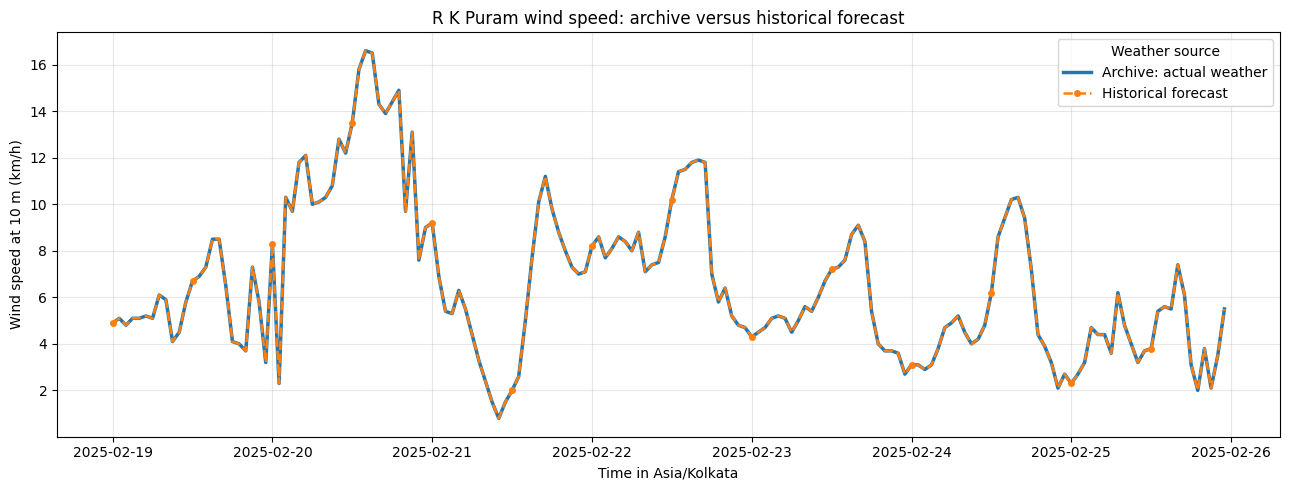

Comparison hours: 168
Mean absolute difference: 0.00 km/h
Maximum absolute difference: 0.00 km/h
The blue solid and orange dashed lines overlap when both sources have the same value.


In [5]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "18_Projects/01_Delhi_Air_Forecast/data/raw/openmeteo").is_dir()
        or (candidate / "data/raw/openmeteo").is_dir()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find the saved data/raw/openmeteo directory.")

raw_root = project_root / "data/raw/openmeteo"
if not raw_root.is_dir():
    raw_root = project_root / "18_Projects/01_Delhi_Air_Forecast/data/raw/openmeteo"

weekly_frames = {}
for source in ("archive", "forecast"):
    rows = []
    for source_file in sorted((raw_root / source).glob("location-17-*.json")):
        with source_file.open(encoding="utf-8") as file:
            payload = json.load(file)
        hourly = payload["hourly"]
        rows.extend(
            zip(
                hourly["time"],
                hourly["wind_speed_10m"],
                strict=True,
            )
        )

    source_frame = pd.DataFrame(rows, columns=["time", "wind_speed_10m"])
    source_frame["time"] = pd.to_datetime(source_frame["time"])
    source_frame = source_frame.set_index("time").sort_index()
    weekly_frames[source] = source_frame.loc["2025-02-19":"2025-02-25"]

wind_week = pd.concat(
    {
        source: frame["wind_speed_10m"]
        for source, frame in weekly_frames.items()
    },
    axis=1,
)
wind_week.columns = ["archive", "forecast"]

if wind_week.isna().any().any():
    raise ValueError("The two wind-speed series are not aligned for the comparison week.")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(
    wind_week.index,
    wind_week["archive"],
    color="tab:blue",
    linestyle="-",
    linewidth=2.5,
    label="Archive: actual weather",
    zorder=2,
)
ax.plot(
    wind_week.index,
    wind_week["forecast"],
    color="tab:orange",
    linestyle="--",
    linewidth=1.8,
    marker="o",
    markersize=4,
    markevery=12,
    label="Historical forecast",
    zorder=3,
)
ax.set_title("R K Puram wind speed: archive versus historical forecast")
ax.set_xlabel("Time in Asia/Kolkata")
ax.set_ylabel("Wind speed at 10 m (km/h)")
ax.grid(True, alpha=0.3)
ax.legend(title="Weather source")
fig.tight_layout()
plt.show()

difference = (wind_week["archive"] - wind_week["forecast"]).abs()
print(f"Comparison hours: {len(wind_week):,}")
print(f"Mean absolute difference: {difference.mean():.2f} km/h")
print(f"Maximum absolute difference: {difference.max():.2f} km/h")
print("The blue solid and orange dashed lines overlap when both sources have the same value.")

### 👀 Read the result

The chart compares **168 hourly wind-speed values** from February 19 through February 25. In this selected week, the archive and historical-forecast values are identical: the mean absolute difference and maximum absolute difference are both **0.00 km/h**.

That does not prove the two sources are always identical. It only tells us that this particular location, period, variable, and API response produced the same wind-speed values. The important result is that the timestamps aligned, the comparison completed without missing values, and we now have evidence for DAF-13 rather than an assumption.

# 🟨 Explanation_2 — Step 6: Record observations for DAF-13

### 🎬 How we got here

We now have two raw weather timelines for the same station and date range. We checked their coverage and compared one week of wind speed. The next useful step is to write down what the evidence says before choosing a modelling source.

### What the evidence says

```text
Archive API                         Historical Forecast API
7 JSON chunks                       7 JSON chunks
13,680 hourly records               13,680 hourly records
570 complete days                   570 complete days
No gaps or duplicates               No gaps or duplicates
             \                       /
              \                     /
               Same wind-speed values
                 for the comparison week
```

### What we can conclude

1. Both APIs returned complete hourly timelines for R K Puram from **2025-02-19 through 2026-09-11**.
2. The two sources can be aligned by timestamp for the selected comparison week.
3. Archive and historical-forecast wind speed were identical for the 168-hour comparison window.
4. This result is evidence for DAF-13, but it is not proof that the sources will always agree.
5. We have not selected a source, joined weather to PM2.5, or trained a model.

### Why DAF-13 still matters

The important difference is not only the values. It is also **when the information was available**. Archive weather describes the realised past; historical-forecast weather represents information that could have been available before the weather happened. DAF-13 must decide which timeline matches the production prediction workflow.

In [6]:
observations = pd.DataFrame(
    [
        {
            "observation": "Archive coverage",
            "result": f"{int(coverage_summary.loc['archive', 'hours']):,} hourly records across {int(coverage_summary.loc['archive', 'days']):,} days",
        },
        {
            "observation": "Forecast coverage",
            "result": f"{int(coverage_summary.loc['forecast', 'hours']):,} hourly records across {int(coverage_summary.loc['forecast', 'days']):,} days",
        },
        {
            "observation": "Timeline quality",
            "result": "Both sources have no missing or duplicate hours",
        },
        {
            "observation": "Wind comparison window",
            "result": f"{len(wind_week):,} aligned hourly records",
        },
        {
            "observation": "Wind-speed difference",
            "result": f"Mean absolute difference {difference.mean():.2f} km/h; maximum {difference.max():.2f} km/h",
        },
    ]
)
display(observations)
print("These observations are evidence for DAF-13; they do not choose the final modelling source.")

,observation,result
0,Archive coverage,"13,680 hourly records across 570 days"
1,Forecast coverage,"13,680 hourly records across 570 days"
2,Timeline quality,Both sources have no missing or duplicate hours
3,Wind comparison window,168 aligned hourly records
4,Wind-speed difference,Mean absolute difference 0.00 km/h; maximum 0....


These observations are evidence for DAF-13; they do not choose the final modelling source.


# Recap — Notebook 12 in one picture

Asha wants tomorrow's forecast to use weather. At 18:00 she can use a weather forecast for tomorrow, but not tomorrow's actual weather. So this notebook collects two versions of the past, side by side, and checks them. It does not decide which one to use. That is for the next ticket.

```text
station coordinates -> two versions of the past -> 7 date ranges in parallel -> save raw JSON -> check every hour -> compare a week of wind
   from stations.csv     archive / historical forecast    14 requests             14 files       13,680 hours each      difference 0.00
```

**How to read the pictures**

- **Picture 1, the journey.** Six cards follow the notebook. Underneath: how the seven date ranges tile the period, and the hour counts that prove nothing is missing.
- **Picture 2, the evidence.** The wind-week comparison, the same comparison for all six variables, where the weather point really sits, and the yearly rhythm of wind and PM2.5.
- **Where the numbers come from.** Read from the 14 JSON files in `data/raw/openmeteo/` and from `data/raw/stations.csv`. Nothing is downloaded again. The all-variables table and the map are extra checks made for this recap.

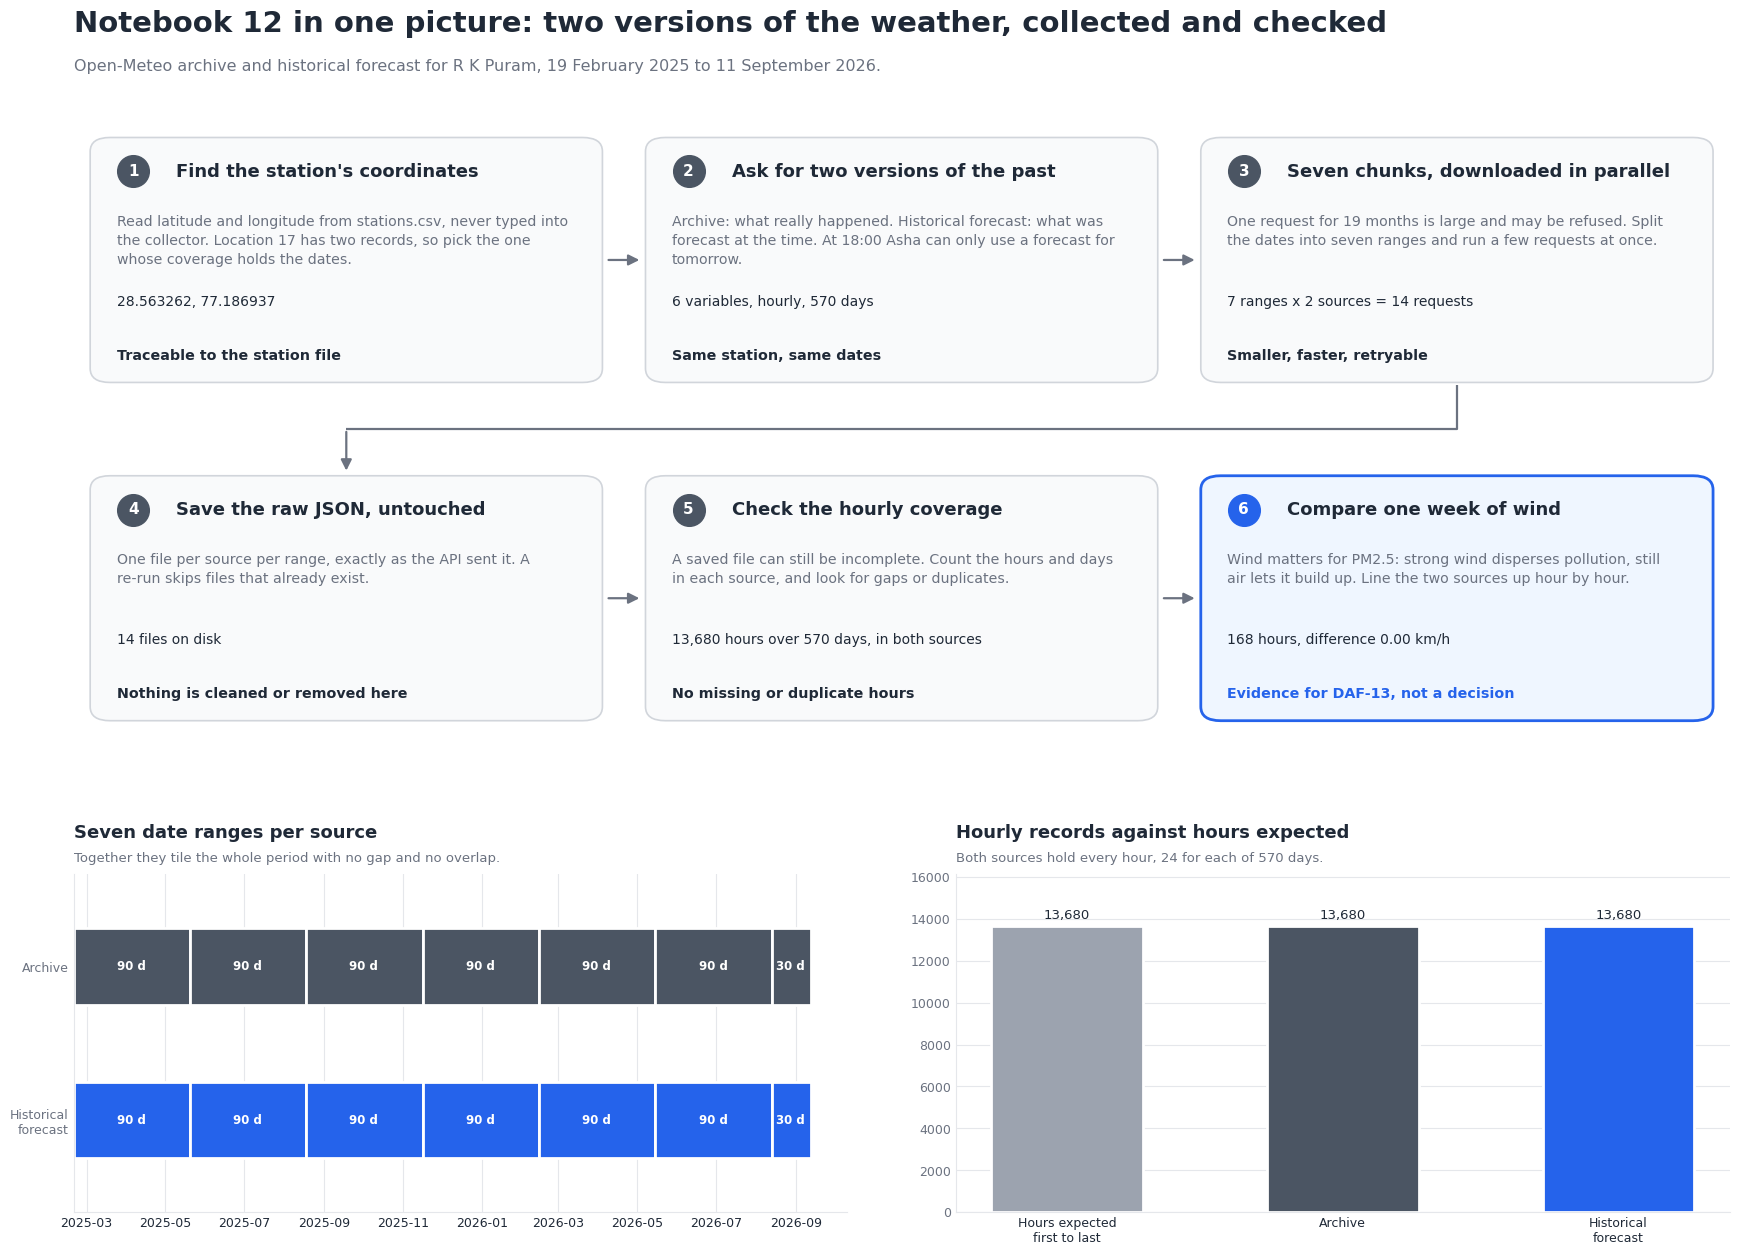

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import recap_style as rs

root = rs.find_project_root()
stations = pd.read_csv(root / "data/raw/stations.csv")
station = stations[stations["sensor_id"] == 12234787].iloc[0]


def read_source(source):
    files = sorted((root / "data/raw/openmeteo" / source).glob("location-17-*.json"))
    payloads = [json.loads(path.read_text(encoding="utf-8")) for path in files]
    hourly = pd.concat([pd.DataFrame(p["hourly"]) for p in payloads], ignore_index=True)
    hourly["time"] = pd.to_datetime(hourly["time"])
    ranges = [tuple(pd.Timestamp(part) for part in (path.stem.split("-", 2)[2][:10], path.stem[-10:])) for path in files]
    return hourly.set_index("time"), payloads, ranges


archive, archive_payloads, archive_ranges = read_source("archive")
forecast, forecast_payloads, forecast_ranges = read_source("forecast")
variables = [c for c in archive.columns]
units = archive_payloads[0]["hourly_units"]
same_time = archive.index.equals(forecast.index)
differing_hours = {v: int(((archive[v] - forecast[v]).abs() > 1e-9).sum()) for v in variables}
expected_hours = len(pd.date_range(archive.index.min(), archive.index.max(), freq="h"))
grid = (archive_payloads[0]["latitude"], archive_payloads[0]["longitude"])

days = archive.index.normalize().nunique()
cards = [
    dict(badge="1", title="Find the station's coordinates", adds="Read latitude and longitude from stations.csv, never typed into the collector. Location 17 has two records, so pick the one whose coverage holds the dates.",
         numbers=f"{station['latitude']:.6f}, {station['longitude']:.6f}", verdict="Traceable to the station file"),
    dict(badge="2", title="Ask for two versions of the past", adds="Archive: what really happened. Historical forecast: what was forecast at the time. At 18:00 Asha can only use a forecast for tomorrow.",
         numbers=f"{len(variables)} variables, hourly, {days} days", verdict="Same station, same dates"),
    dict(badge="3", title="Seven chunks, downloaded in parallel", adds="One request for 19 months is large and may be refused. Split the dates into seven ranges and run a few requests at once.",
         numbers=f"{len(archive_ranges)} ranges x 2 sources = {len(archive_ranges) + len(forecast_ranges)} requests", verdict="Smaller, faster, retryable"),
    dict(badge="4", title="Save the raw JSON, untouched", adds="One file per source per range, exactly as the API sent it. A re-run skips files that already exist.",
         numbers=f"{len(archive_ranges) + len(forecast_ranges)} files on disk", verdict="Nothing is cleaned or removed here"),
    dict(badge="5", title="Check the hourly coverage", adds="A saved file can still be incomplete. Count the hours and days in each source, and look for gaps or duplicates.",
         numbers=f"{len(archive):,} hours over {days} days, in both sources", verdict="No missing or duplicate hours"),
    dict(badge="6", title="Compare one week of wind", adds="Wind matters for PM2.5: strong wind disperses pollution, still air lets it build up. Line the two sources up hour by hour.",
         numbers="168 hours, difference 0.00 km/h", verdict="Evidence for DAF-13, not a decision", kind="final"),
]

flow_h = rs.flow_size(len(cards), 3)
fig = plt.figure(figsize=(rs.FIG_W, flow_h + 4.8), facecolor="white")
grid_spec = fig.add_gridspec(2, 2, height_ratios=[flow_h, 4.8], hspace=0.3, wspace=0.14, left=0.05, right=0.97, top=0.9, bottom=0.09)
rs.header(fig, "Notebook 12 in one picture: two versions of the weather, collected and checked",
          "Open-Meteo archive and historical forecast for R K Puram, 19 February 2025 to 11 September 2026.")
rs.draw_cards(fig.add_subplot(grid_spec[0, :]), cards, cols=3)

chunks = fig.add_subplot(grid_spec[1, 0])
for row, (label, ranges, color) in enumerate((("Archive", archive_ranges, rs.BASE_BAR), ("Historical forecast", forecast_ranges, rs.ACCENT))):
    for start, end in ranges:
        chunks.barh(row, (end - start).days + 1, left=start, height=0.5, color=color, edgecolor="white", linewidth=2)
        chunks.text(start + (end - start) / 2, row, f"{(end - start).days + 1} d", ha="center", va="center", fontsize=8.5, color="white", fontweight="bold")
chunks.set_yticks([0, 1], ["Archive", "Historical\nforecast"])
chunks.set_ylim(-0.6, 1.6)
chunks.invert_yaxis()
chunks.tick_params(axis="x", labelsize=8.5)
rs.style_axis(chunks, "Seven date ranges per source", "Together they tile the whole period with no gap and no overlap.", grid_axis="x")

coverage = fig.add_subplot(grid_spec[1, 1])
names = ["Hours expected\nfirst to last", "Archive", "Historical\nforecast"]
values = [expected_hours, len(archive), len(forecast)]
bars = coverage.bar(names, values, color=[rs.BAR, rs.BASE_BAR, rs.ACCENT], width=0.55, edgecolor="white", linewidth=2)
coverage.set_ylim(0, max(values) * 1.18)
rs.label_bars(coverage, bars, fmt="{:,.0f}")
rs.style_axis(coverage, "Hourly records against hours expected", f"Both sources hold every hour, 24 for each of {days} days.")
plt.show()

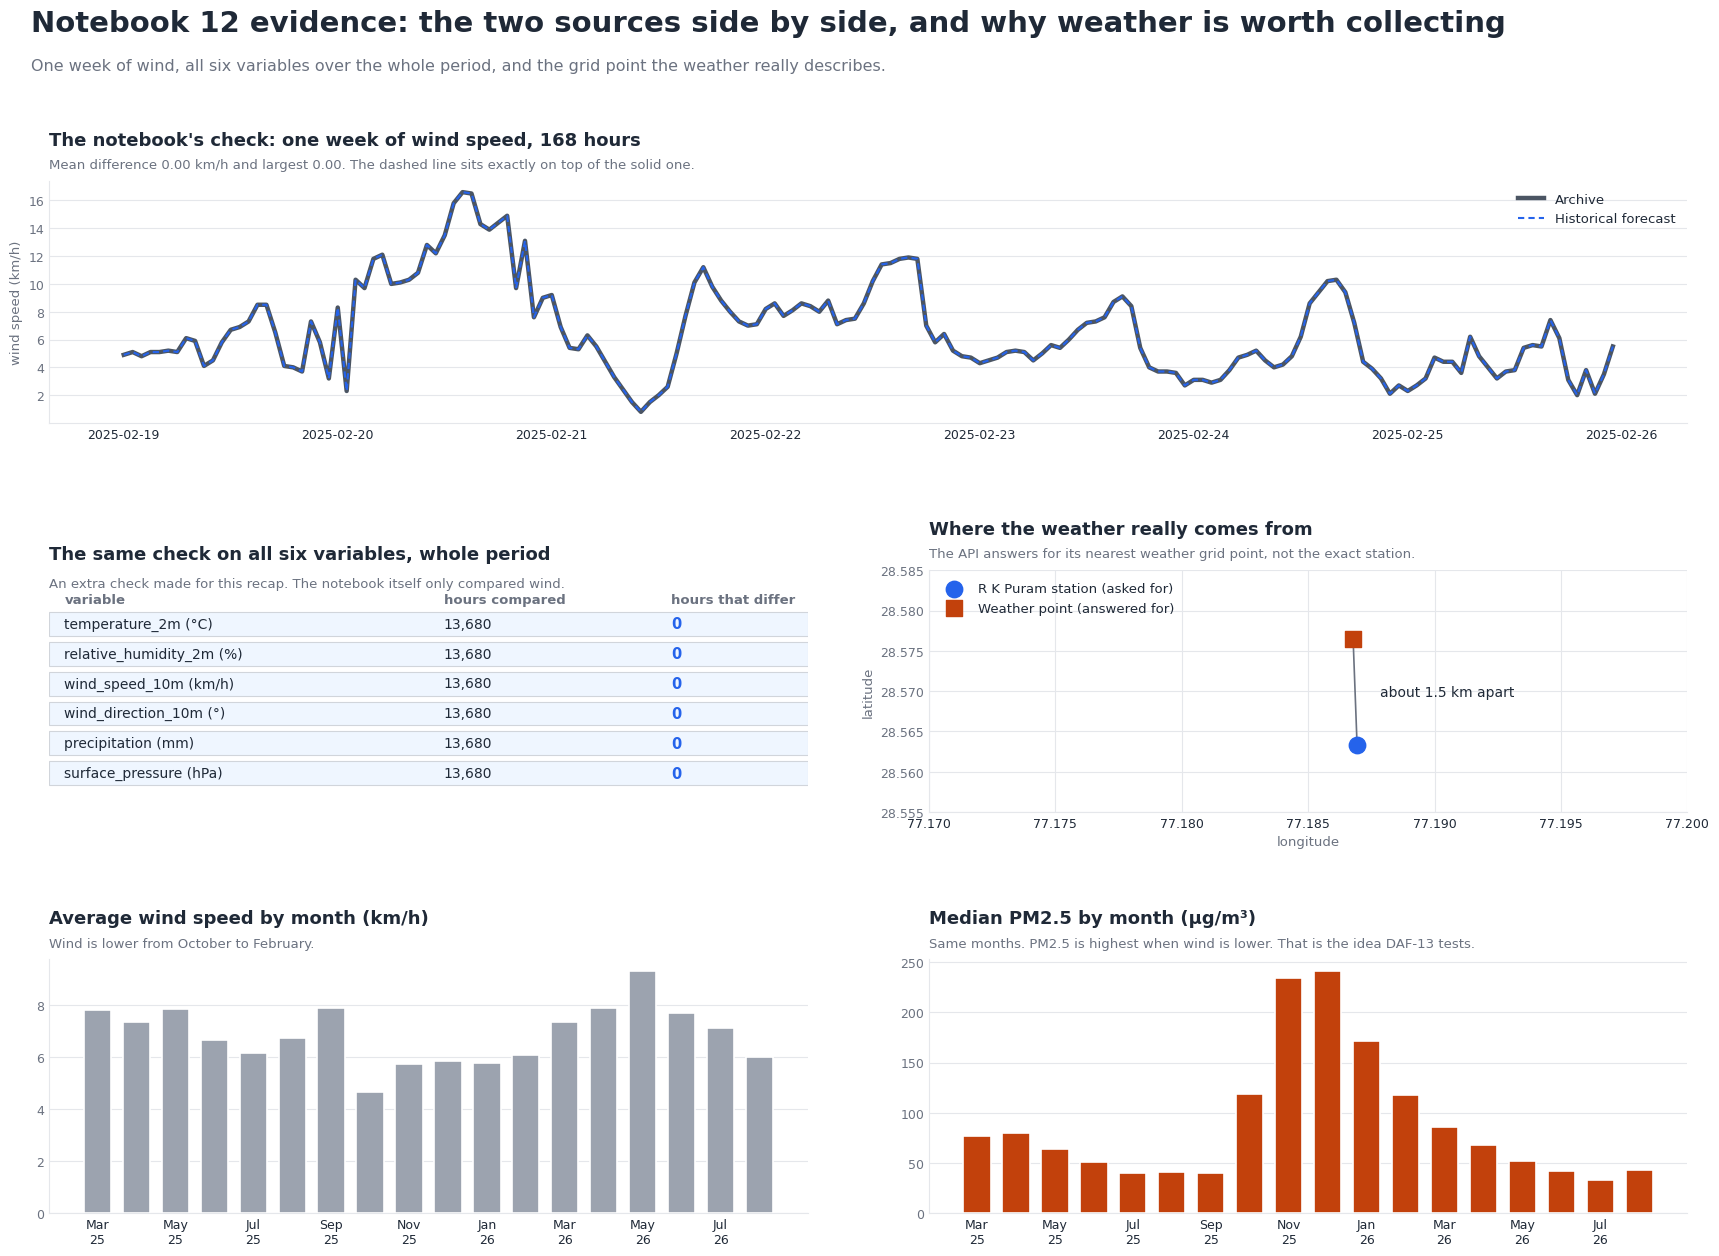

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import recap_style as rs

root = rs.find_project_root()
stations = pd.read_csv(root / "data/raw/stations.csv")
station = stations[stations["sensor_id"] == 12234787].iloc[0]


def read_source(source):
    files = sorted((root / "data/raw/openmeteo" / source).glob("location-17-*.json"))
    payloads = [json.loads(path.read_text(encoding="utf-8")) for path in files]
    hourly = pd.concat([pd.DataFrame(p["hourly"]) for p in payloads], ignore_index=True)
    hourly["time"] = pd.to_datetime(hourly["time"])
    ranges = [tuple(pd.Timestamp(part) for part in (path.stem.split("-", 2)[2][:10], path.stem[-10:])) for path in files]
    return hourly.set_index("time"), payloads, ranges


archive, archive_payloads, archive_ranges = read_source("archive")
forecast, forecast_payloads, forecast_ranges = read_source("forecast")
variables = [c for c in archive.columns]
units = archive_payloads[0]["hourly_units"]
same_time = archive.index.equals(forecast.index)
differing_hours = {v: int(((archive[v] - forecast[v]).abs() > 1e-9).sum()) for v in variables}
expected_hours = len(pd.date_range(archive.index.min(), archive.index.max(), freq="h"))
grid = (archive_payloads[0]["latitude"], archive_payloads[0]["longitude"])

station_point = (station["latitude"], station["longitude"])
offset_km = np.hypot((grid[0] - station_point[0]) * 111.0, (grid[1] - station_point[1]) * 111.0 * np.cos(np.radians(station_point[0])))

fig = plt.figure(figsize=(rs.FIG_W, 13), facecolor="white")
spec = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.05], hspace=0.6, wspace=0.16, left=0.06, right=0.97, top=rs.top_margin(fig, 1.9), bottom=0.06)
rs.header(fig, "Notebook 12 evidence: the two sources side by side, and why weather is worth collecting",
          "One week of wind, all six variables over the whole period, and the grid point the weather really describes.")

week = fig.add_subplot(spec[0, :])
window = slice("2025-02-19 00:00", "2025-02-25 23:00")
week.plot(archive.loc[window].index, archive.loc[window, "wind_speed_10m"], color=rs.BASE_BAR, linewidth=3.2, label="Archive")
week.plot(forecast.loc[window].index, forecast.loc[window, "wind_speed_10m"], color=rs.ACCENT, linewidth=1.5, linestyle=(0, (3, 2)), label="Historical forecast")
difference = (archive.loc[window, "wind_speed_10m"] - forecast.loc[window, "wind_speed_10m"]).abs()
week.set_ylabel(f"wind speed ({units['wind_speed_10m']})", fontsize=9.5, color=rs.MUTED)
week.legend(frameon=False, fontsize=9.5, loc="upper right", labelcolor=rs.INK)
rs.style_axis(week, "The notebook's check: one week of wind speed, 168 hours",
              f"Mean difference {difference.mean():.2f} km/h and largest {difference.max():.2f}. The dashed line sits exactly on top of the solid one.")

table = fig.add_subplot(spec[1, 0])
table.set_xlim(0, 10)
table.set_ylim(len(variables) + 0.6, -1.5)
table.axis("off")
table.set_title("The same check on all six variables, whole period", loc="left", fontsize=13, fontweight="bold", color=rs.INK, pad=8)
table.text(0, -1.05, "An extra check made for this recap. The notebook itself only compared wind.", fontsize=9.5, color=rs.MUTED, va="center")
for x, header in ((0.2, "variable"), (5.2, "hours compared"), (8.2, "hours that differ")):
    table.text(x, -0.5, header, fontsize=9.5, fontweight="bold", color=rs.MUTED, va="center")
for i, variable in enumerate(variables):
    y = i + 0.3
    table.add_patch(plt.Rectangle((0, y - 0.4), 10, 0.8, facecolor=rs.ACCENT_FILL if differing_hours[variable] == 0 else rs.ALERT_FILL, edgecolor=rs.CARD_EDGE, linewidth=0.8))
    table.text(0.2, y, f"{variable} ({units[variable]})", va="center", fontsize=10, color=rs.INK)
    table.text(5.2, y, f"{len(archive):,}", va="center", fontsize=10, color=rs.INK)
    table.text(8.2, y, str(differing_hours[variable]), va="center", fontsize=10.5, fontweight="bold", color=rs.ACCENT if differing_hours[variable] == 0 else rs.ALERT)

point = fig.add_subplot(spec[1, 1])
point.scatter([station_point[1]], [station_point[0]], s=140, color=rs.ACCENT, zorder=3, label="R K Puram station (asked for)")
point.scatter([grid[1]], [grid[0]], s=140, marker="s", color=rs.ALERT, zorder=3, label="Weather point (answered for)")
point.plot([station_point[1], grid[1]], [station_point[0], grid[0]], color=rs.MUTED, linewidth=1.2, zorder=2)
point.annotate(f"about {offset_km:.1f} km apart", ((station_point[1] + grid[1]) / 2, (station_point[0] + grid[0]) / 2), xytext=(18, 0), textcoords="offset points", fontsize=10, color=rs.INK, va="center")
point.set_xlim(77.17, 77.20)
point.set_ylim(28.555, 28.585)
point.set_xlabel("longitude", fontsize=9.5, color=rs.MUTED)
point.set_ylabel("latitude", fontsize=9.5, color=rs.MUTED)
point.legend(frameon=False, fontsize=9.5, loc="upper left", labelcolor=rs.INK)
rs.style_axis(point, "Where the weather really comes from", "The API answers for its nearest weather grid point, not the exact station.", grid_axis="both")

pm25 = pd.read_csv(root / "data/interim/daily_17.csv", parse_dates=["date"], index_col="date")["pm25_mean"].dropna()
pm25.index = pm25.index.tz_convert("Asia/Kolkata").tz_localize(None)
months = pd.period_range("2025-03", "2026-08", freq="M")
wind_monthly = archive["wind_speed_10m"].groupby(archive.index.to_period("M")).mean().reindex(months)
pm25_monthly = pm25.groupby(pm25.index.to_period("M")).median().reindex(months)
x = np.arange(len(months))
labels = [m.strftime("%b\n%y") if i % 2 == 0 else "" for i, m in enumerate(months)]
wind_axis = fig.add_subplot(spec[2, 0])
wind_axis.bar(x, wind_monthly.values, color=rs.BAR, width=0.7, edgecolor="white", linewidth=1.2)
wind_axis.set_xticks(x, labels, fontsize=8)
rs.style_axis(wind_axis, "Average wind speed by month (km/h)", "Wind is lower from October to February.")
pm_axis = fig.add_subplot(spec[2, 1])
pm_axis.bar(x, pm25_monthly.values, color=rs.ALERT, width=0.7, edgecolor="white", linewidth=1.2)
pm_axis.set_xticks(x, labels, fontsize=8)
rs.style_axis(pm_axis, "Median PM2.5 by month (µg/m³)", "Same months. PM2.5 is highest when wind is lower. That is the idea DAF-13 tests.")
plt.show()

### Recap in five lines

1. **Take coordinates from the station file, not from a typed number.** Location 17 has two records, so the code picks the one whose coverage contains the requested dates.
2. **There are two versions of the past.** The archive says what happened. The historical forecast says what was forecast at the time. The second is the one the live service could really have at 18:00.
3. **Split a big download.** Seven date ranges per source, fetched a few at a time, keep each request small. Re-running skips files that already exist, and the raw JSON is never edited.
4. **A saved file can still be incomplete.** Both sources hold 13,680 hourly records over 570 days, with no missing or duplicate hours.
5. **The two sources match here.** One week of wind differs by 0.00 km/h. The extra check in this recap found the same for all six variables over the whole period, so any difference between the two versions will have to come from somewhere other than these numbers. That is evidence for DAF-13, not a choice.

**If you remember only one thing:** collect the evidence first and decide later. Two sources that agree exactly are a finding, not a reason to stop checking.